# 1. Импорты, seed и среда

In [1]:
import random
from typing import Dict, List, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from datasets import Dataset, DatasetDict, load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42) # СВЯЩЕННОЕ ЧИСЛО

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

dataset = load_dataset("emotion")
print(dataset)

/home/saparch/playground/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


# 2. Данные и первичный анализ

In [2]:
df_train = dataset["train"].to_pandas()
df_val = dataset["validation"].to_pandas()
df_test = dataset["test"].to_pandas()

df = pd.concat([df_train, df_val, df_test])

label_names = dataset['train'].features['label'].names
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for idx, label in enumerate(label_names)}

df["label_id"] = df["label"].map(label2id)

print("label2id:", label2id)
print("id2label:", id2label)

display(df.sample(6, random_state=42).reset_index(drop=True))

print("Размер ВСЕГО датасета:", len(df))
display(df["label"].value_counts())

print("\nРаспределение классов в train:")
display(df_train["label"].value_counts())

print("Распределение классов в validation:")
display(df_val["label"].value_counts())

print("Распределение классов в test:")
display(df_test["label"].value_counts())

label2id: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


,text,label,label_id
0,i noticed several months ago that i d start feeling resentful as i walked toward a pedestrian crossing with the intention of course of c...,3,NaN
1,i love lots of different kinds of sports and love hanging out with my friends in my free time i also have an unhealthy up session with g...,1,NaN
2,i feel even if he killed himself it was because he was agonized to that extent,0,NaN
3,i feel numb the way a wound does before it really starts to hurt,0,NaN
4,i feel very happy to have inspired is my little sis love of reading and writing,1,NaN
5,i began to feel unimportant useless insecure and i was disconnected from everything that i used to know,0,NaN


Размер ВСЕГО датасета: 20000


label
1    6761
0    5797
3    2709
4    2373
2    1641
5     719
Name: count, dtype: int64


Распределение классов в train:


label
1    5362
0    4666
3    2159
4    1937
2    1304
5     572
Name: count, dtype: int64

Распределение классов в validation:


label
1    704
0    550
3    275
4    212
2    178
5     81
Name: count, dtype: int64

Распределение классов в test:


label
1    695
0    581
3    275
4    224
2    159
5     66
Name: count, dtype: int64

In [3]:
# Посмотрим на несколько примеров.
print("Пример из train:")
display(dataset["train"][:3])

print("Пример из validation:")
display(dataset["validation"][:3])

print(dataset['train'].features['label'])
# или
print(dataset['train'].info.features['label'].names)

Пример из train:


{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong'],
 'label': [0, 0, 3]}

Пример из validation:


{'text': ['im feeling quite sad and sorry for myself but ill snap out of it soon',
  'i feel like i am still looking at a blank canvas blank pieces of paper',
  'i feel like a faithful servant'],
 'label': [0, 0, 2]}

ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])
['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


## Это датасет классификации эмоций (emotion detection / sentiment classification).
6 классов:
- sadness (грусть)
- joy (радость)
- love (любовь)
- anger (гнев)
- fear (страх)
- surprise (удивление)

## Задача: по тексту на английском языке предсказать, какую эмоцию выражает автор.
Это типичная задача text classification (многоклассовая, 6 классов). Отличный выбор для учебного задания по fine-tuning BERT — модель учится предсказывать эмоцию по тексту.

# 3. Токенизация

In [4]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model checkpoint:", MODEL_NAME)

def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = dataset.map(tokenize_batch, batched=True)

# Удаляем столбец "text": DataCollatorWithPadding попытается преобразовать
# все поля датасета в тензоры, а строки в тензор не конвертируются.
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets

Tokenizer loaded: BertTokenizer
Model checkpoint: distilbert-base-uncased


DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [5]:
for i in range(5):
    print(55*"-", f"TOKENIZED EXAMPLE {i}", 55*"-")
    example = tokenized_datasets["train"][i]
    print("Ключи примера:", example.keys())
    print("labels:", example["label"])
    print("input_ids[:20]:", example["input_ids"][:20])
    print("attention_mask[:20]:", example["attention_mask"][:20])
    
    print("\nДекодированный текст по input_ids:")
    print(tokenizer.decode(example["input_ids"]))

------------------------------------------------------- TOKENIZED EXAMPLE 0 -------------------------------------------------------
Ключи примера: dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])
labels: 0
input_ids[:20]: [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask[:20]: [1, 1, 1, 1, 1, 1, 1]

Декодированный текст по input_ids:
[CLS] i didnt feel humiliated [SEP]
------------------------------------------------------- TOKENIZED EXAMPLE 1 -------------------------------------------------------
Ключи примера: dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])
labels: 0
input_ids[:20]: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998]
attention_mask[:20]: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Декодированный текст по input_ids:
[CLS] i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake [

In [10]:
# Data collator будет добавлять padding динамически, прямо при формировании батча.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(6)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")

# Загружаем модель для классификации.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)

input_ids: shape=(6, 23)
token_type_ids: shape=(6, 23)
attention_mask: shape=(6, 23)
labels: shape=(6,)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 11706.45it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model class: DistilBertForSequenceClassification
Number of labels: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


# 4. Инференс готовой модели

In [11]:
# Вспомогательная функция для ручного инференса одного текста.
def predict_one_text(text: str) -> Dict[str, Any]:
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        outputs = model(**encoded)

    logits = outputs.logits
    probs = F.softmax(logits, dim=-1)

    pred_id = int(torch.argmax(probs, dim=-1).item())
    pred_label = model.config.id2label[pred_id]
    pred_score = float(probs[0, pred_id].item())

    result = {
        "text": text,
        "pred_id": pred_id,
        "pred_label": pred_label,
        "pred_score": pred_score,
        "logits": logits.cpu().numpy().round(4).tolist()[0],
        "probabilities": probs.cpu().numpy().round(4).tolist()[0],
    }
    return result

# Удобная функция для преобразования вероятностей в таблицу.
def probability_table(text: str) -> pd.DataFrame:
    result = predict_one_text(text)
    labels = [model.config.id2label[i] for i in range(model.config.num_labels)]
    df = pd.DataFrame(
        {
            "label": labels,
            "probability": result["probabilities"],
        }
    ).sort_values("probability", ascending=False, ignore_index=True)
    df.insert(0, "text", text)
    return df


In [12]:
demo_texts = [
    "I'm so happy today! Everything is wonderful!",
    "I'm really scared of what might happen",
    "I love you so much, you're amazing",
    "This is absolutely disgusting and frustrating",
    "I can't believe this happened, I'm so surprised",
    "I feel so sad and lonely lately"
]
for i in range(5):
    print(55*"-", f"DEMO {i}", 55*"-")
    single_example = demo_texts[i]
    manual_result = predict_one_text(single_example)
    
    display(pd.DataFrame(
        {
            "field": list(manual_result.keys()),
            "value": [manual_result[key] for key in manual_result.keys()],
        }
    ))
for i in range(5):
    print(55*"-", f"PROBS FOR DEMO {i}", 55*"-")
    display(probability_table(demo_texts[i]))

------------------------------------------------------- DEMO 0 -------------------------------------------------------


,field,value
0,text,I'm so happy today! Everything is wonderful!
1,pred_id,4
2,pred_label,fear
3,pred_score,0.1884
4,logits,"[-0.04100000113248825, 0.048700001090765, -0.2117999941110611, 0.021800000220537186, 0.08969999849796295, -0.13819999992847443]"
5,probabilities,"[0.16529999673366547, 0.18080000579357147, 0.13940000534057617, 0.17599999904632568, 0.188400000333786, 0.15000000596046448]"


------------------------------------------------------- DEMO 1 -------------------------------------------------------


,field,value
0,text,I'm really scared of what might happen
1,pred_id,1
2,pred_label,joy
3,pred_score,0.1795
4,logits,"[-0.011699999682605267, 0.04769999906420708, -0.16050000488758087, 0.026900000870227814, 0.029999999329447746, -0.11029999703168869]"
5,probabilities,"[0.16920000314712524, 0.17949999868869781, 0.14579999446868896, 0.17579999566078186, 0.17640000581741333, 0.15330000221729279]"


------------------------------------------------------- DEMO 2 -------------------------------------------------------


...

,text,label,probability
0,"I love you so much, you're amazing",fear,0.1861
1,"I love you so much, you're amazing",joy,0.1812
2,"I love you so much, you're amazing",anger,0.1749
3,"I love you so much, you're amazing",sadness,0.1596
4,"I love you so much, you're amazing",surprise,0.1516
5,"I love you so much, you're amazing",love,0.1467


------------------------------------------------------- PROBS FOR DEMO 3 -------------------------------------------------------


,text,label,probability
0,This is absolutely disgusting and frustrating,joy,0.1823
1,This is absolutely disgusting and frustrating,fear,0.1766
2,This is absolutely disgusting and frustrating,anger,0.1758
3,This is absolutely disgusting and frustrating,sadness,0.1663
4,This is absolutely disgusting and frustrating,surprise,0.1594
5,This is absolutely disgusting and frustrating,love,0.1397


------------------------------------------------------- PROBS FOR DEMO 4 -------------------------------------------------------


,text,label,probability
0,"I can't believe this happened, I'm so surprised",fear,0.1819
1,"I can't believe this happened, I'm so surprised",joy,0.1792
2,"I can't believe this happened, I'm so surprised",anger,0.1780
3,"I can't believe this happened, I'm so surprised",sadness,0.1675
4,"I can't believe this happened, I'm so surprised",surprise,0.1529
5,"I can't believe this happened, I'm so surprised",love,0.1404


In [13]:
# Функция метрик для Trainer.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

# Общие параметры обучения.
common_training_kwargs = dict(
    output_dir="outputs/hw13_bert_finetuning_demo",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )



In [14]:
# Собираем Trainer и запускаем обучение.
# В transformers >= 5.0 аргумент tokenizer переименован в processing_class.
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.362143,0.262846,0.924500,0.895909,0.925411
2,0.123605,0.181841,0.936500,0.909722,0.935798
3,0.001347,0.199118,0.939500,0.913517,0.939916
4,0.209358,0.234401,0.939000,0.913018,0.939212
5,0.000363,0.275050,0.939500,0.910960,0.939210


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.64it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=10000, training_loss=0.1733866853020285, metrics={'train_runtime': 1445.5127, 'train_samples_per_second': 55.344, 'train_steps_per_second': 6.918, 'total_flos': 853624920666528.0, 'train_loss': 0.1733866853020285, 'epoch': 5.0})

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.7865,3.9923,1.9998e-05,0.001,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.7725,2.0561,1.9994e-05,0.002,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.7255,3.3106,1.9990e-05,0.003,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.7331,3.8916,1.9986e-05,0.004,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.7429,2.9125,1.9982e-05,0.005,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.7599,2.6418,1.9978e-05,0.006,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.6316,2.7223,1.9974e-05,0.007,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.6886,3.6072,1.9970e-05,0.008,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1.5631,3.3462,1.9966e-05,0.009,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.7518,5.3125,1.9962e-05,0.010,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


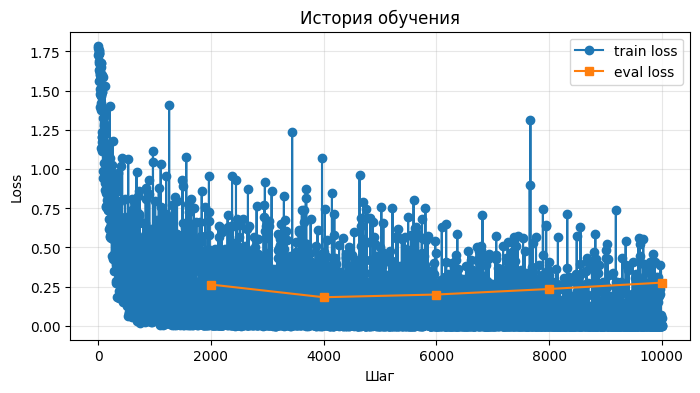

In [15]:
# История логов Trainer.
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("История обучения")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("./artifacts/training_curves.png")
plt.show()


In [16]:
# В transformers >= 5.x NotebookProgressCallback теряет состояние после обучения,
# что вызывает RuntimeError при вызове evaluate() вне тренировочного цикла.
# Удаляем его перед standalone-оценкой – это стандартный обходной путь.
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

# Оценка Trainer на validation и test.
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")


Validation metrics:
eval_loss: 0.1991
eval_accuracy: 0.9395
eval_f1_macro: 0.9135
eval_f1_weighted: 0.9399
eval_runtime: 7.4234
eval_samples_per_second: 269.4180
eval_steps_per_second: 33.6770
epoch: 5.0000

Test metrics:
eval_loss: 0.2385
eval_accuracy: 0.9295
eval_f1_macro: 0.8903
eval_f1_weighted: 0.9297
eval_runtime: 7.5368
eval_samples_per_second: 265.3660
eval_steps_per_second: 33.1710
epoch: 5.0000


Classification report on test:
              precision    recall  f1-score   support

     sadness       0.97      0.96      0.97       581
         joy       0.94      0.95      0.95       695
        love       0.85      0.81      0.83       159
       anger       0.92      0.93      0.93       275
        fear       0.89      0.90      0.90       224
    surprise       0.73      0.82      0.77        66

    accuracy                           0.93      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.93      0.93      0.93      2000



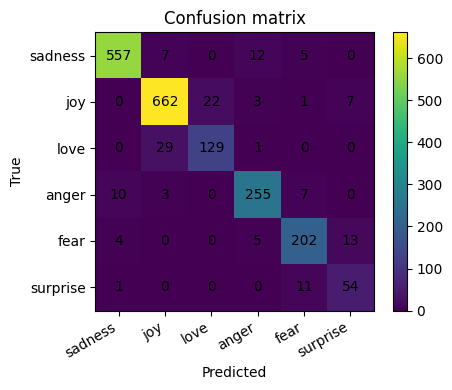

In [17]:
# Детальные предсказания на тестовой выборке.
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

print("Classification report on test:")
print(
    classification_report(
        test_true,
        test_preds,
        target_names=[id2label[i] for i in range(len(id2label))],
        zero_division=0,
    )
)

cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("./artifacts/confusion_matrix.png")
plt.show()

In [18]:
# Вспомогательная функция для инференса новых текстов.
def predict_texts(texts: List[str]) -> pd.DataFrame:
    encoded = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**encoded)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()

    pred_ids = probs.argmax(axis=1)

    rows = []
    for text, pred_id, prob_vector in zip(texts, pred_ids, probs):
        row = {
            "text": text,
            "pred_label": id2label[int(pred_id)],
            "confidence": float(prob_vector[pred_id]),
        }
        for class_id, class_name in id2label.items():
            row[f"prob_{class_name}"] = float(prob_vector[class_id])
        rows.append(row)

    return pd.DataFrame(rows)

new_texts = [
    "I'm so happy! Everything is great!",  # joy
    "I'm terrified of the dark",  # fear
    "I love you so much",  # love
    "This is disgusting and awful",  # anger
    "I didn't expect this at all!",  # surprise
    "I feel so lonely and empty"  # sadness
]

display(predict_texts(new_texts))

,text,pred_label,confidence,prob_sadness,prob_joy,prob_love,prob_anger,prob_fear,prob_surprise
0,I'm so happy! Everything is great!,joy,0.9999,2.8170e-05,9.9987e-01,4.8492e-05,1.4640e-05,1.0156e-05,2.5729e-05
1,I'm terrified of the dark,fear,0.9995,9.8552e-05,6.1898e-05,2.0592e-05,1.9153e-04,9.9954e-01,8.3957e-05
2,I love you so much,love,0.9678,5.5901e-04,3.1065e-02,9.6784e-01,3.3881e-04,1.2025e-04,7.6316e-05
3,This is disgusting and awful,anger,0.9959,3.6261e-03,1.4860e-04,8.4536e-05,9.9586e-01,1.8681e-04,9.8519e-05
4,I didn't expect this at all!,anger,0.9884,1.3836e-03,1.5029e-03,9.0422e-05,9.8840e-01,8.3926e-03,2.3175e-04
5,I feel so lonely and empty,sadness,0.9998,9.9981e-01,3.8922e-05,2.0846e-05,7.2607e-05,3.8356e-05,1.5515e-05


In [21]:
# Таблица ошибок на тестовой выборке.
test_texts = df_test.reset_index(drop=True)["text"]
error_rows = []

for text, true_id, pred_id, prob_vector in zip(test_texts, test_true, test_preds, torch.softmax(torch.tensor(test_logits), dim=-1).numpy()):
    if true_id != pred_id:
        error_rows.append({
            "text": text,
            "true_label": id2label[int(true_id)],
            "pred_label": id2label[int(pred_id)],
            "confidence": float(prob_vector[pred_id]),
        })

errors_df = pd.DataFrame(error_rows)

if len(errors_df) == 0:
    print("На тестовой выборке ошибок не найдено. Это возможно на маленьком учебном датасете.")
else:
    display(errors_df.sort_values(by="confidence", ascending=False).reset_index(drop=True))

errors_df.to_csv("./artifacts/sample_predictions.csv")

,text,true_label,pred_label,confidence
0,whenever i put myself in others shoes and try to make the person happy,anger,joy,0.9998
1,i feel i can only hope im not alone in these thoughts and im sure to all you fellow exchange students you probably have the same thought...,sadness,joy,0.9996
2,i feel fucking woeful looking at the other girls,sadness,joy,0.9996
3,i feel affirmed gracious sensuous and will have less self doubt when a href http generations,love,joy,0.9996
4,i walked to school he felt the bounce in his step the overjoyed feelings of youth and the thrill of excitement of coming to school and m...,love,joy,0.9995
...,...,...,...,...
136,i don t know how else to describe it except to say that i had the same feeling about three weeks before my beloved grandmother passed away,joy,love,0.5126
137,i was feeling weird the other day and it went away about minutes after i took my metformin,fear,surprise,0.5089
138,i felt like id developed feelings for this guy thus explaining why id even follow this guy like a faithful puppy dog and he never knew,joy,love,0.5041
139,i wonder if the homeowners would feel weird if i parked to gape at their landscaping,surprise,fear,0.5025
